# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import skew
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import explained_variance_score, mean_absolute_error, root_mean_squared_error
import shap
import pickle


c:\Users\seyed\miniconda3\envs\dsi_participant\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


## Exploratory Data Analysis

The main task of this peice of work is to train a regression model to predict the **burned area** of forest fires in hectares. First, we run some analysis and visualization to understand its distribution before modeling. This step is crucial because, for instance, skewed target variables can negatively impact regression models by biasing predictions toward frequent small values and being disproportionately influenced by outliers.

count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64
Skewness of 'area': 12.809629951754577


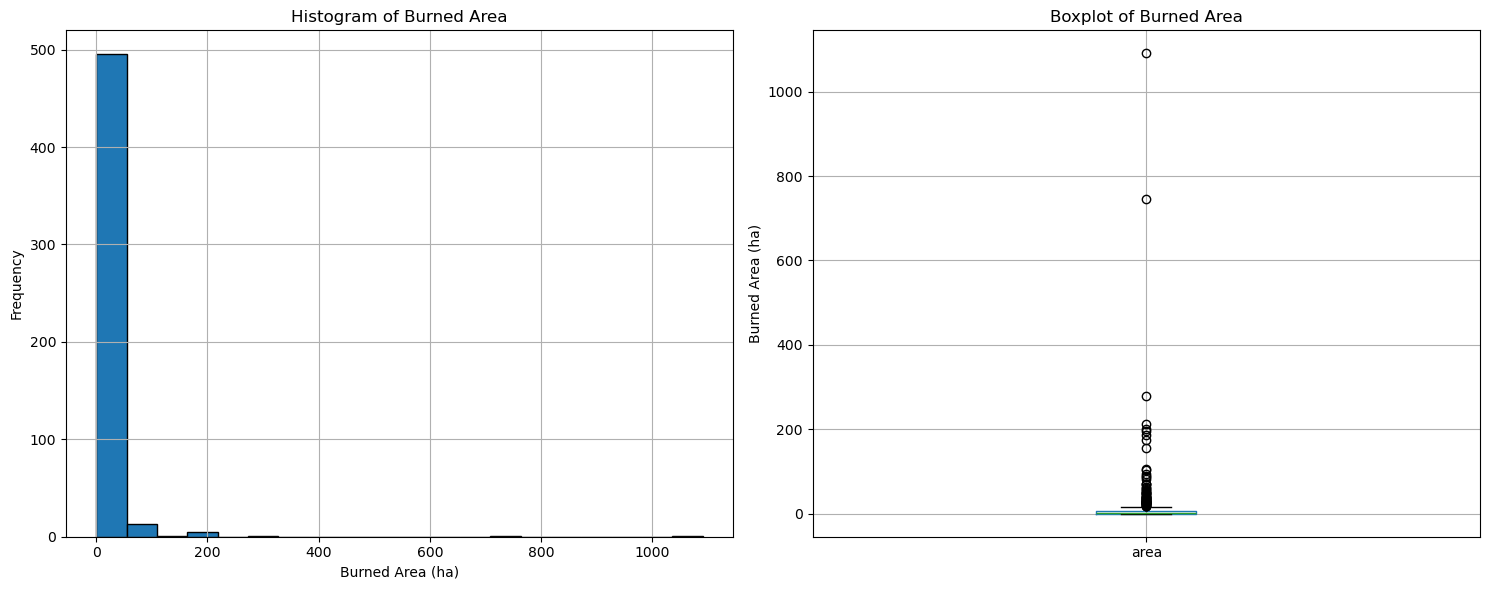

In [3]:
# Statistical summary of the target variable
print(fires_dt['area'].describe())

# Calculate skewness
area_skewness = skew(fires_dt['area'])
print(f"Skewness of 'area': {area_skewness}")

# Plot histogram
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
fires_dt['area'].hist(bins=20, edgecolor='k')
plt.title('Histogram of Burned Area')
plt.xlabel('Burned Area (ha)')
plt.ylabel('Frequency')

# Boxplot to visualize outliers
plt.subplot(1,2,2)
fires_dt.boxplot(column='area')
plt.title('Boxplot of Burned Area')
plt.ylabel('Burned Area (ha)')

#plt.subplots_adjust(wspace=.5)
plt.tight_layout()
plt.show()



A statistical summary shows a significant difference between the mean and median, suggesting right skewness, which was confirmed by a highly positive skewness value (>5) and visualizations of histograms and boxplots showing a long right tail with many small fires and a few extreme cases of large burned areas. To address this, we applied a logarithmic transformation *(ln(area+1))*, which stabilized variance and reduced the impact of outliers, ensuring that models would generalize better and make more accurate predictions.

# Get X and Y

Create the features data frame and target data.

In [4]:
# Log-transform the target variable to handle skewness
fires_dt['log_area'] = fires_dt['area'].apply(lambda x: np.log1p(x))

# Split into features (X) and target (y)
X = fires_dt.drop(columns=['area', 'log_area'])
y = fires_dt['log_area']


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


## Discussion:

For the second preprocessor, apply the Yeo-Johnson power transformation to numerical features to stabilize variance and reduce skewness. To determine which features require transformation, first visualize the distribution of each feature using histograms to assess their skewness. Based on the results, apply the transformation only to features with an absolute skewness value greater than 1 `(∣skew∣>1)`. This targeted approach ensures that the transformation is applied where it is most needed, improving data symmetry and making the features more suitable for modeling without overcomplicating preprocessing.

According to the above discussion, `isi`, `dc`, `ffmc` are proper candidates for the power transformation based on the skewness metric!

<Figure size 1500x600 with 0 Axes>

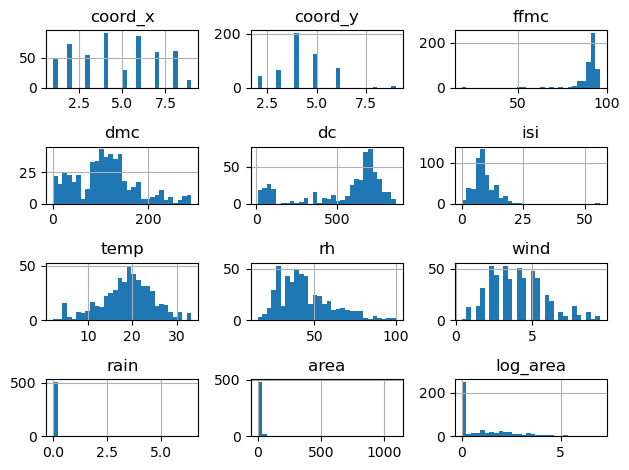

In [6]:
plt.figure(figsize=(15,6))
fires_dt.hist(bins=30)
plt.tight_layout()
plt.show()


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [7]:
numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

preprocess_1 = ColumnTransformer([
    ('standardizer', StandardScaler(), numeric_features),
    ('one-hot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
preprocess_1

ColumnTransformer(transformers=[('standardizer', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('one-hot',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['month', 'day'])])

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [8]:
numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']
numeric_features_transform = ['ffmc', 'isi', 'dc']


preprocess_2 = ColumnTransformer([
    ('transform', PowerTransformer(method='yeo-johnson'), numeric_features_transform),
    ('standardizer', StandardScaler(), numeric_features),
    ('one-hot', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
preprocess_2

ColumnTransformer(transformers=[('transform', PowerTransformer(),
                                 ['ffmc', 'isi', 'dc']),
                                ('standardizer', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('one-hot',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['month', 'day'])])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [9]:
baseline_regressor = Ridge(random_state=123)
advanced_regressor = RandomForestRegressor(random_state=123)


In [10]:
# Pipeline A = preproc1 + baseline
pipe_A = Pipeline([
    ('preprocessing', preprocess_1),
    ('regressor', baseline_regressor)
])
pipe_A

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardizer',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('one-hot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', Ridge(random_state=123))])

In [11]:
# Pipeline B = preproc2 + baseline
pipe_B = Pipeline([
    ('preprocessing', preprocess_2),
    ('regressor', baseline_regressor)
])
pipe_B

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('transform',
                                                  PowerTransformer(),
                                                  ['ffmc', 'isi', 'dc']),
                                                 ('standardizer',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('one-hot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', Ridge(random_state=123))])

In [12]:
# Pipeline C = preproc1 + advanced model
pipe_C = Pipeline([
    ('preprocessing', preprocess_1),
    ('regressor', advanced_regressor)
])
pipe_C

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('standardizer',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('one-hot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=123))])

In [13]:
# Pipeline D = preproc2 + advanced model
pipe_D = Pipeline([
    ('preprocessing', preprocess_2),
    ('regressor', advanced_regressor)
])
pipe_D

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('transform',
                                                  PowerTransformer(),
                                                  ['ffmc', 'isi', 'dc']),
                                                 ('standardizer',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('one-hot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor(random_state=123))])

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [14]:
param_grid_ridge = {'regressor__alpha':[0.1, 1, 10]}
scoring = ['explained_variance', 'neg_root_mean_squared_error', 'neg_mean_absolute_error' ]

grid_cv_A = GridSearchCV(
    estimator=pipe_A, 
    param_grid=param_grid_ridge, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_mean_absolute_error")
grid_cv_A.fit(X_train, y_train)

pipe_A_best = grid_cv_A.best_estimator_
root_mean_A = np.sqrt(mean_absolute_error(y_test, pipe_A_best.predict(X_test)))
print(f"The Mean Absolute Error of the first pipeline is:  {root_mean_A:.2f}")

The Mean Absolute Error of the first pipeline is:  1.07


In [15]:
param_grid_ridge = {'regressor__alpha':[0.1, 1, 10]}
scoring = ['explained_variance', 'neg_root_mean_squared_error', 'neg_mean_absolute_error' ]

grid_cv_B = GridSearchCV(
    estimator=pipe_B, 
    param_grid=param_grid_ridge, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_mean_absolute_error")
grid_cv_B.fit(X_train, y_train)

pipe_B_best = grid_cv_B.best_estimator_
root_mean_B = np.sqrt(mean_absolute_error(y_test, pipe_B_best.predict(X_test)))
print(f"The Mean Absolute Error of the second pipeline is:  {root_mean_B:.2f}")

The Mean Absolute Error of the second pipeline is:  1.07


In [16]:
param_grid_rf = {'regressor__n_estimators':[50, 100, 200], 'regressor__max_depth': [None, 30]}
scoring = ['explained_variance', 'neg_root_mean_squared_error', 'neg_mean_absolute_error' ]

grid_cv_C = GridSearchCV(
    estimator=pipe_C, 
    param_grid=param_grid_rf, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_mean_absolute_error")
grid_cv_C.fit(X_train, y_train)



pipe_C_best = grid_cv_C.best_estimator_
root_mean_C = np.sqrt(mean_absolute_error(y_test, pipe_C_best.predict(X_test)))
print(f"The Mean Absolute Error of the third pipeline is:  {root_mean_C:.2f}")

The Mean Absolute Error of the third pipeline is:  1.11


In [17]:
param_grid_rf = {'regressor__n_estimators':[50, 100, 200], 'regressor__max_depth': [None, 30]}
scoring = ['explained_variance', 'neg_root_mean_squared_error', 'neg_mean_absolute_error' ]

grid_cv_D = GridSearchCV(
    estimator=pipe_D, 
    param_grid=param_grid_rf, 
    scoring = scoring, 
    cv = 5,
    refit = "neg_mean_absolute_error")
grid_cv_D.fit(X_train, y_train)

pipe_D_best = grid_cv_D.best_estimator_
root_mean_D = np.sqrt(mean_absolute_error(y_test, pipe_D_best.predict(X_test)))
print(f"The Mean Absolute Error of the fourth pipeline is:  {root_mean_D:.2f}")

The Mean Absolute Error of the fourth pipeline is:  1.11


# Evaluate

+ Which model has the best performance?

<span style= 'color:green; font-weight:bold'> Answer </span>:

According to the Mean Absolute Value metric evaluation, the first model with the following structure is the best:

In [21]:
grid_cv_B.best_params_

{'regressor__alpha': 10}

# Export

+ Save the best performing model to a pickle file.

In [22]:
best_model = grid_cv_A.best_estimator_
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

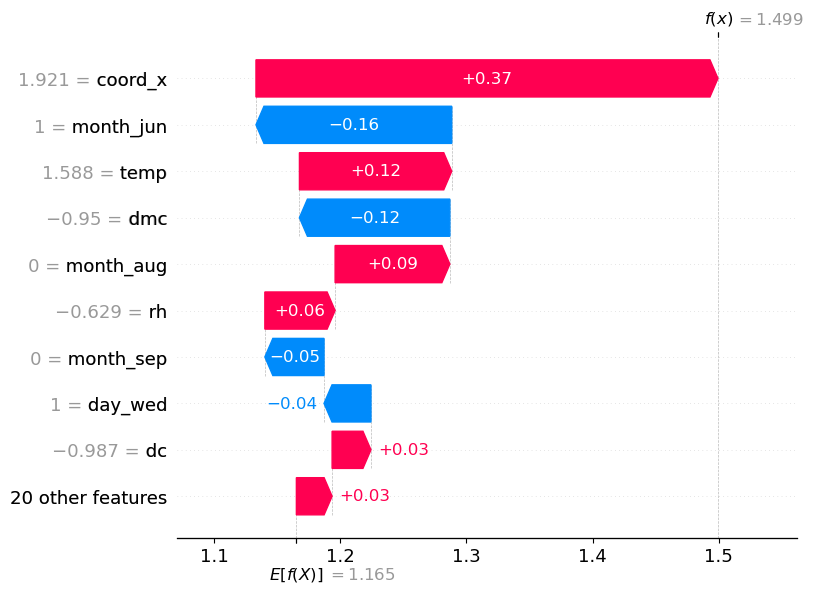

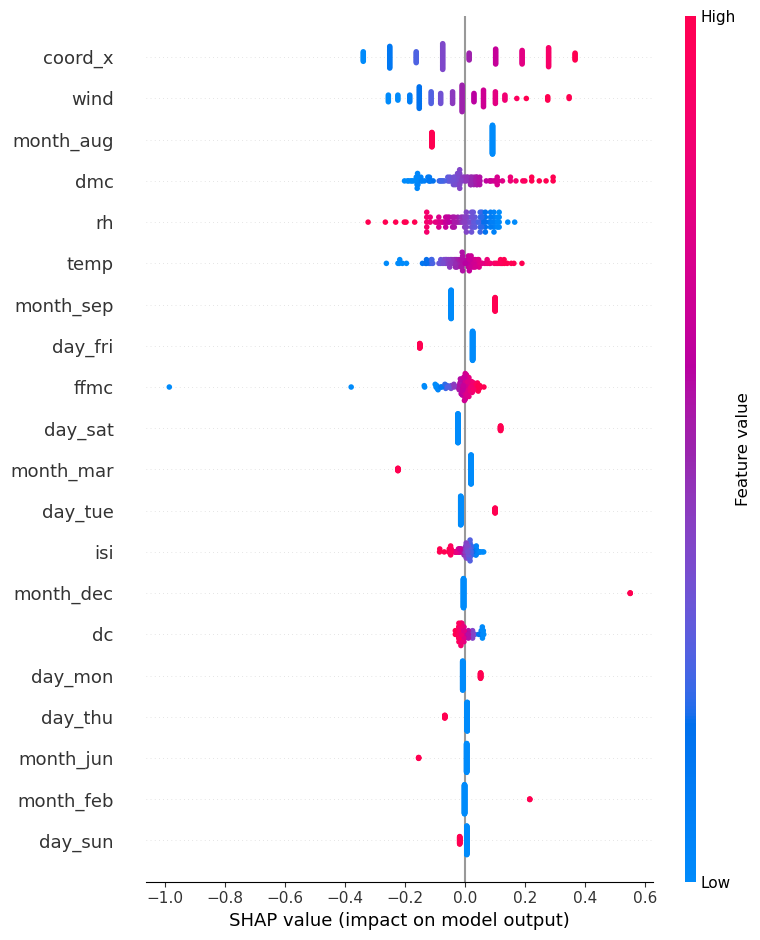

In [23]:
categorical_features = best_model['preprocessing'].named_transformers_['one-hot'].get_feature_names_out(['month', 'day'])
features = list(numeric_features) + list(categorical_features)


# Preprocess the data using the pipeline's preprocessing step
X_train_processed = best_model['preprocessing'].transform(X_train)
X_test_processed = best_model['preprocessing'].transform(X_test)


explainer = shap.Explainer(best_model['regressor'], X_train_processed)
shap_values = explainer(X_test_processed)


# Create a SHAP Explanation object for a single observation
shap_explanation = shap.Explanation(
    values=shap_values[0].values,
    base_values=shap_values[0].base_values,
    data=X_test_processed[0],
    feature_names=features  # Provide feature names here
)

# Local explanation for a single observation
shap.plots.waterfall(shap_explanation)


# Global explanation for feature importance
shap.summary_plot(shap_values, X_test_processed, feature_names=features)

<span style = 'color:green;font-weight:bold'> Discussion </span>:

For a specific observation in the test set, SHAP values show the most influential features contributing to the prediction, highlighting both positive and negative impacts. For instance, features like **temp** might have **strong positive** contributions to predicting larger burned areas, while features like **Duff Moisture Code (DMC)** might **negatively impact** predictions due to its mitigating effect on fire spread. Globally, across the training set, SHAP values can be aggregated to identify the most and least important features; for example, **temp** and **wind** might emerge as **critical predictors** of fire spread, while less impactful variables like **Drought Code (DC)** , and **the days of the week** could be **candidates for removal**. To test whether removing such features enhances model performance, an ablation study can be conducted by retraining the model without these features and comparing metrics like RMSE or MAE. This approach ensures that only meaningful features are retained, improving model interpretability and efficiency.


## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.